In [1]:
# import the libraries 
import os
import argparse
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.animation import FFMpegWriter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from netCDF4 import Dataset
from wrf import getvar, latlon_coords, to_np
import pandas as pd
from datetime import datetime, timedelta

In [2]:
# set the colors for the plot and the levels for the scale 
colors = [
    "#c6f7d0",  # very light green
    "#7be495",  # light green
    "#3ac569",  # green
    "#f5f57a",  # yellow
    "#ffb347",  # orange
    "#ff7043",  # dark orange
    "#ff0000",  # red
    "#cc00cc",  # purple
    "#660066",  # dark purple
]

levels = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

cmap = ListedColormap(colors)
norm = BoundaryNorm(levels, cmap.N)

In [3]:
#  this function converts WRF (UTC) time to EAT
def format_eat_time(wrf_time_raw):
    ts = pd.to_datetime(str(wrf_time_raw))
    eat_time = ts + timedelta(hours=3)
    return eat_time.strftime('%d %b %Y | %H:%M EAT') 

In [4]:
def run_filtered_rainfall(wrf_path, selected_counties=None):
    # --- 1. SETUP & DATA ---
    ncfile = Dataset(wrf_path)
    all_counties = gpd.read_file("/home/erickwambugu/WEATHER/WORKFLOW/map_shapefile_kenya/ke_shp/ke.shp")
    
    # Filter counties based on your list
    if selected_counties:
        # Ensure the names match your 'counties' print output (case-sensitive)
        counties = all_counties[all_counties['name'].isin(selected_counties)]
    else:
        counties = all_counties


    # Dynamic Extent: Zoom to selected counties with a small buffer
    bounds = counties.total_bounds  # [minx, miny, maxx, maxy]
    lon_min, lat_min, lon_max, lat_max = bounds
    buffer = 0.1  # degrees buffer for better visualization
    extent = [lon_min - buffer, lon_max + buffer, lat_min - buffer, lat_max + buffer]

    # --- 2. RAINFALL CALCULATION ---
    rain_start = getvar(ncfile, "RAINC", timeidx=0) + getvar(ncfile, "RAINNC", timeidx=0)
    rain_end = getvar(ncfile, "RAINC", timeidx=-1) + getvar(ncfile, "RAINNC", timeidx=-1)
    rain_total = rain_end - rain_start
    lats, lons = latlon_coords(rain_start)

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(12, 15))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Map Styling and  applying map features 
    ax.add_feature(cfeature.OCEAN, facecolor="#0974b3", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
    ax.add_feature(cfeature.LAKES, facecolor="#0974b3", edgecolor="blue", alpha=0.3, zorder=1)
    ax.add_feature(cfeature.RIVERS, facecolor="#0974b3", edgecolor="blue", alpha=0.3, zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=2, zorder=4)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=2, zorder=4)
    
    # Plot only the filtered county boundaries
    counties.boundary.plot(ax=ax, edgecolor="black", linewidth=1, zorder=5)

    # Add labels for selected counties
    for _, row in counties.iterrows():
        ax.text(
            row.geometry.centroid.x, 
            row.geometry.centroid.y, 
            row['name'],
            transform=ccrs.PlateCarree(), 
            fontsize=8, 
            fontweight='bold', 
            ha='center',
            zorder=4
        )

    #  plot the glidlines and the labels for the latitudes and longitudes
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                            color='grey', alpha=0.3, linestyle='--')
        
    gl.top_labels =     gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'fontsize': 10, 'color': 'black'}
    gl.ylabel_style = {'fontsize': 10, 'color': 'black'}


    contour = ax.contourf(to_np(lons), to_np(lats), to_np(rain_total),
                          levels=levels, cmap=cmap, norm=norm, extend="max", 
                          transform=ccrs.PlateCarree(), zorder=2, alpha=0.8)
    
    plt.colorbar(
        contour, ax=ax, orientation="horizontal", 
        pad=0.03, shrink=0.8, label="Total Cumulative Rainfall (mm)",
        extend="max"
    )

    # Dynamic Title
    start_time_str = format_eat_time(getvar(ncfile, "Times", timeidx=0).values)
    end_time_str = format_eat_time(getvar(ncfile, "Times", timeidx=-1).values)
    county_str = ", ".join(selected_counties) if selected_counties else "KENYA"
    
    plt.title(
        f"24-Hour Cumulative Rainfall Forecast\nArea: {county_str}\nValid: {start_time_str} <<>> {end_time_str}", 
        fontsize=14, 
        fontweight="bold"
    )


    # output_dir = "/home/erickwambugu/WRF/outputs"
    # plt.savefig(os.path.join(path_to_output_dir, "name_rainfall.png"), dpi=300, bbox_inches="tight")
    plt.show()

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


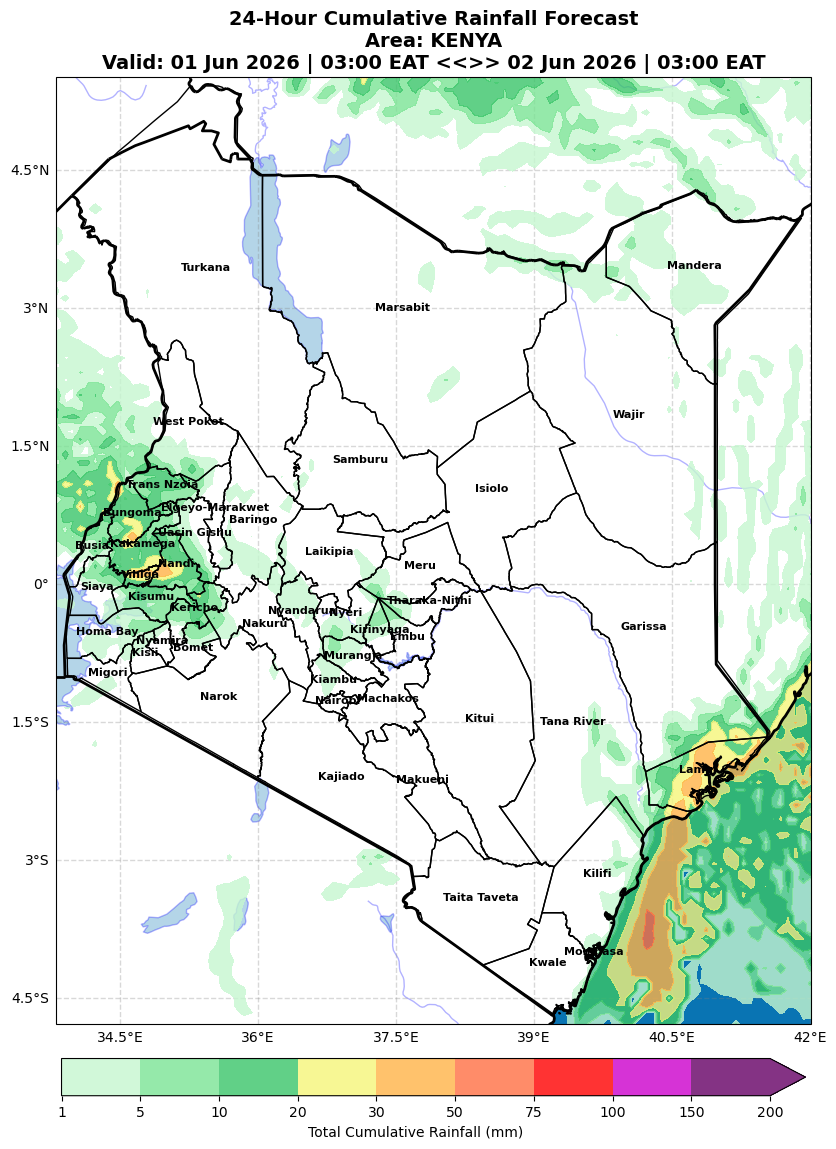

In [5]:
run_filtered_rainfall(
    wrf_path="/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00",
    selected_counties=[]
)

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


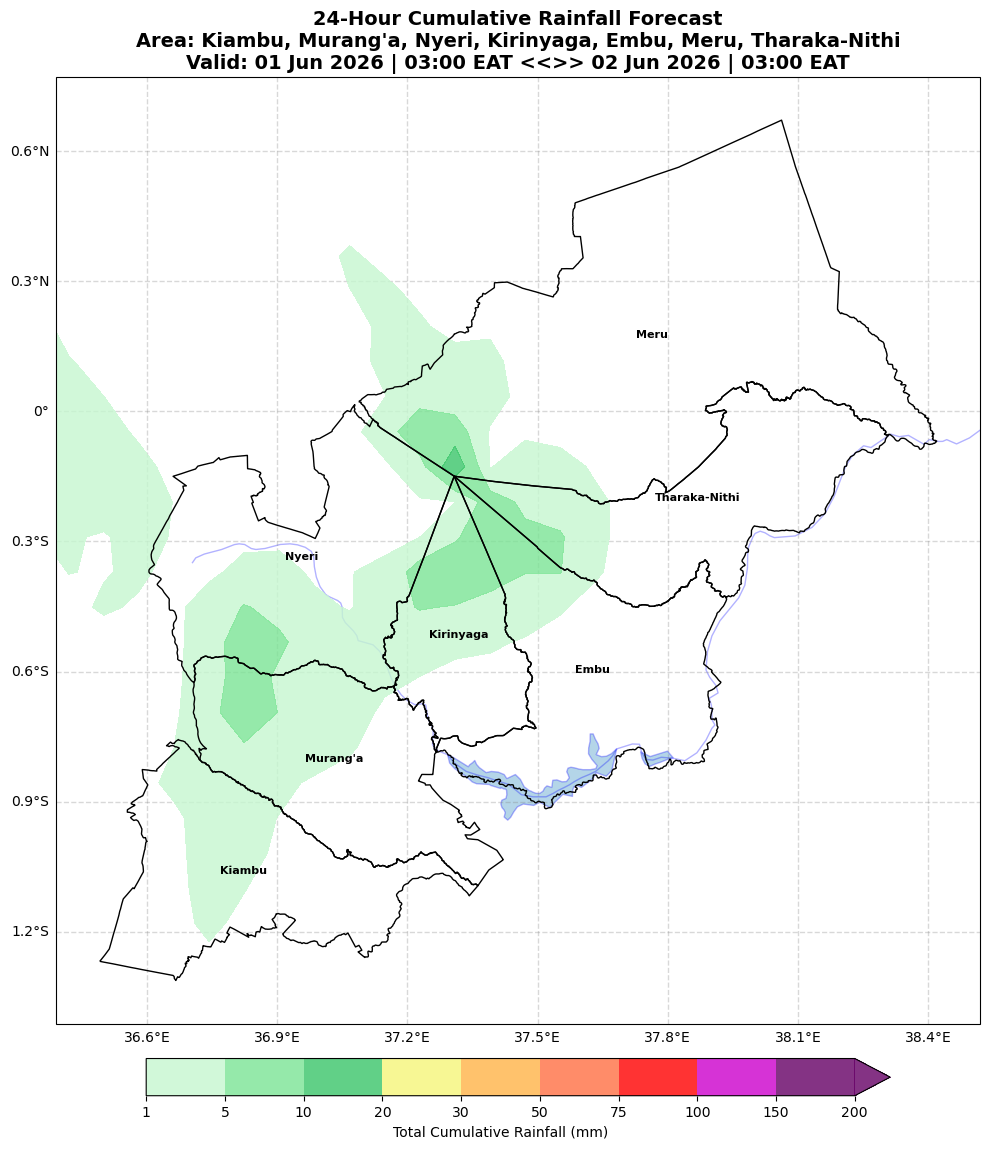

In [6]:
# central region 
run_filtered_rainfall(
    wrf_path="/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00",
    selected_counties=["Kiambu", "Murang'a", "Nyeri", "Kirinyaga", "Embu", "Meru", "Tharaka-Nithi"]
)

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


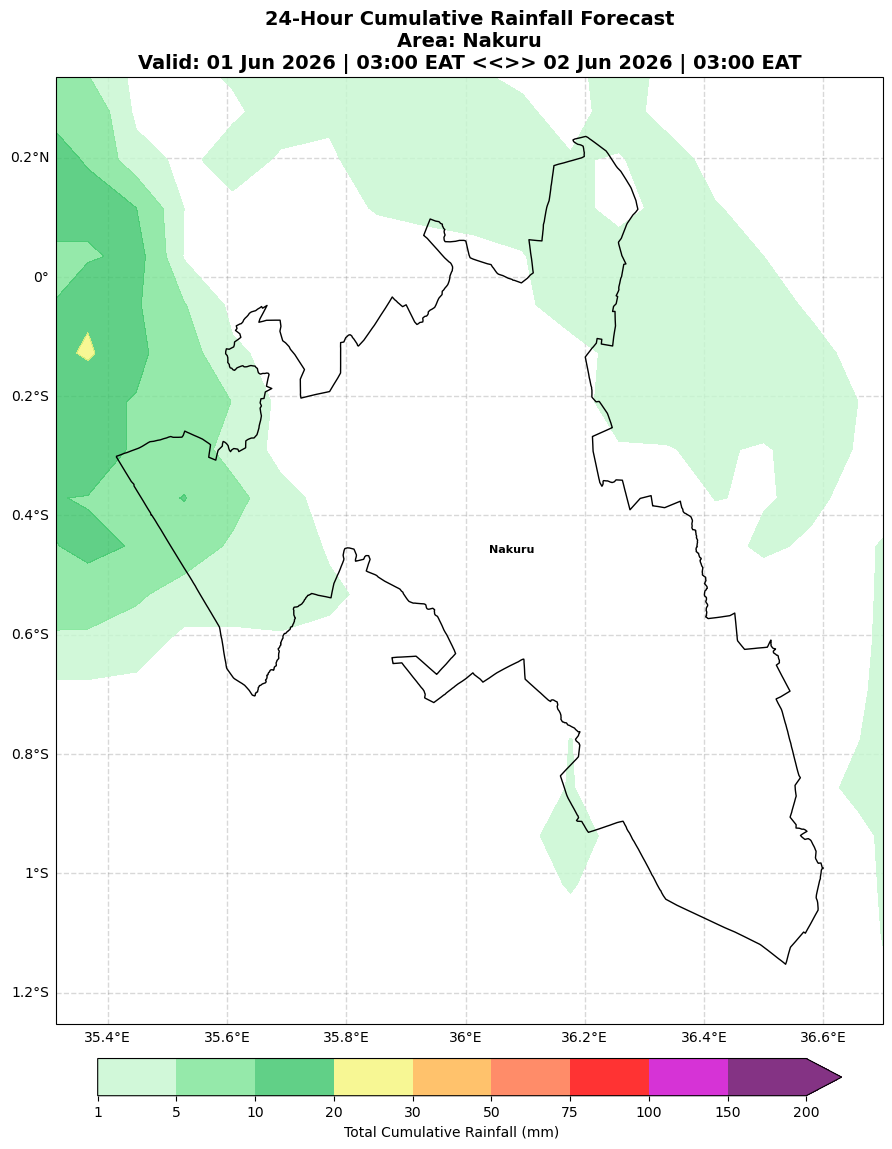

In [7]:
run_filtered_rainfall(
    wrf_path="/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00",
    selected_counties=["Nakuru"]
)

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


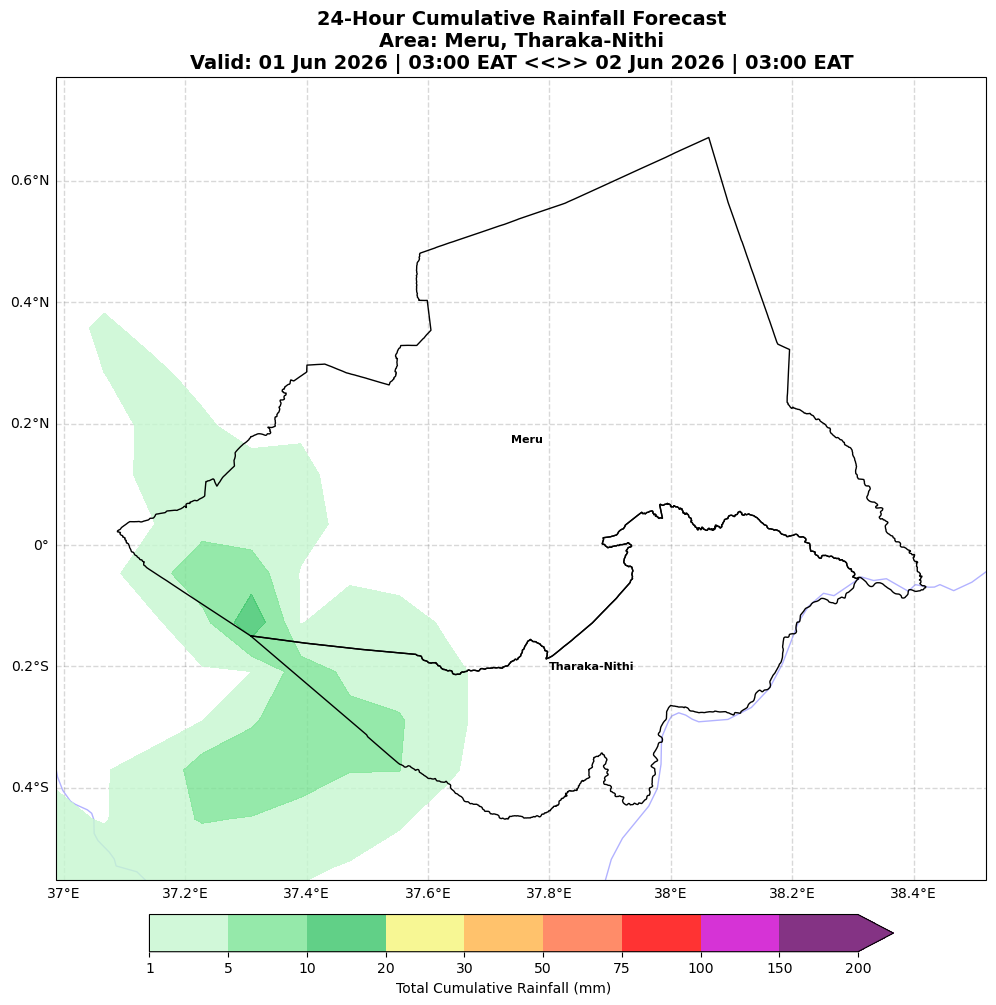

In [8]:
run_filtered_rainfall(
    wrf_path="/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00",
    selected_counties=["Meru", "Tharaka-Nithi"]
)

/home/erickwambugu/miniconda3/envs/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


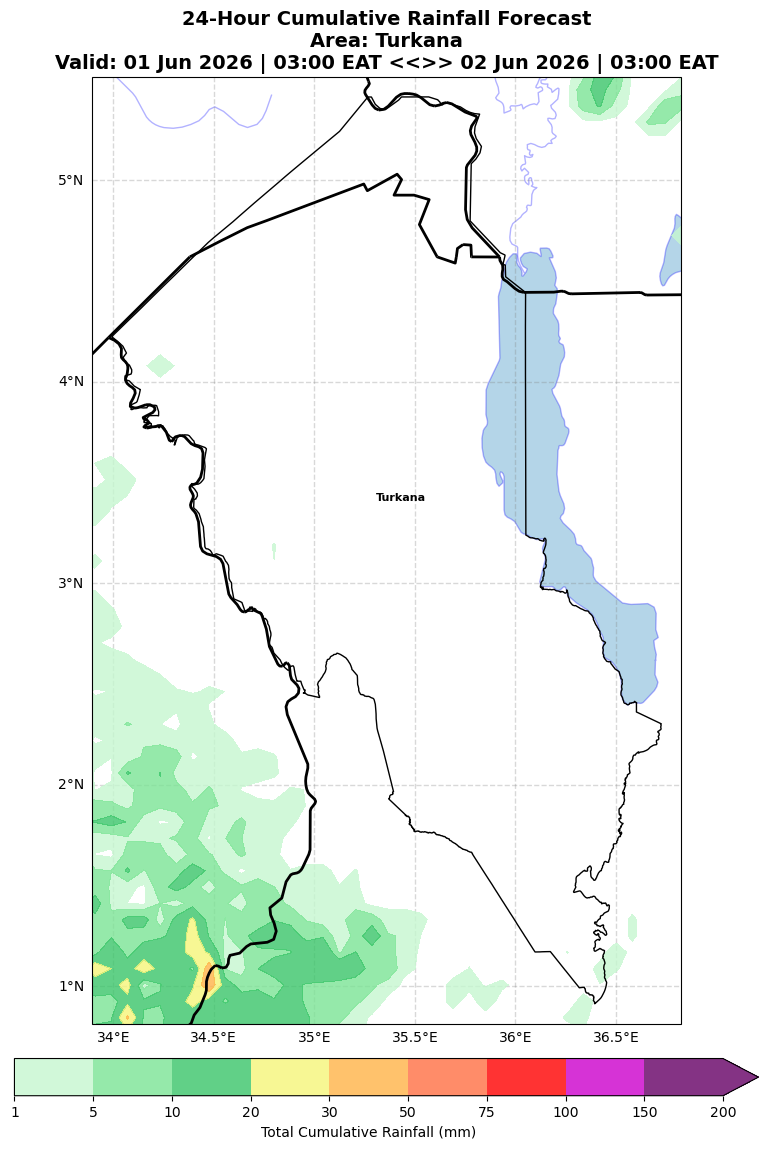

In [9]:
run_filtered_rainfall(
    wrf_path="/home/erickwambugu/WRF/run/wrfout_d01_2026-06-01_00:00:00",
    selected_counties=["Turkana"]
)